In [1]:
from pathlib import Path
import numpy as np
from astropy import units as u
from astropy.table import Table

from telescope import *
from spectrograph import *
from detector import *
import synphot
from etc.etc import SpecETC

from matplotlib import pyplot as plt

LRIS-B-600: Reading spectrograph efficiency from /Users/jwalawender/git/SpecETC/data/LRIS-Blue/600_mirr_eff.dat
IMX183: Reading detector efficiency from /Users/jwalawender/git/SpecETC/data/SonyIMX/QE.csv
IMX533: Reading detector efficiency from /Users/jwalawender/git/SpecETC/data/SonyIMX/QE.csv


In [2]:
pickles_readme_file = Path('~/pysynphot_models/grid/pickles/AA_README').expanduser()
with open(pickles_readme_file) as f:
    readme = f.readlines()
pickles_readme_table = Table.read(readme[113:193], format='ascii', names=('file', 'SPTYPE', 'Teff'))

In [3]:
types = [str(spt) for spt in set(pickles_readme_table['SPTYPE'])]
for ty in ['O', 'B', 'A', 'F', 'G', 'K', 'M']:
    subtypes = [st for st in types if st[0] == ty]
    print(ty, subtypes)

O ['O8III', 'O5V', 'O9V']
B ['B8V', 'B5I', 'B8I', 'B0I', 'B9III', 'B1V', 'B5-7V', 'B2II', 'B5III', 'B5II', 'B3V', 'B1-2III', 'B6IV', 'B2IV', 'B0V']
A ['A0I', 'A0IV', 'A5III', 'A0III', 'A2V', 'A3V', 'A0V', 'A5V', 'A4-7IV']
F ['F5III', 'F5IV', 'F0III', 'F2V', 'F5I', 'F5V', 'F8IV', 'F2II', 'F8I', 'F0II', 'F8V', 'F0-2IV', 'F0V', 'F0I']
G ['G0I', 'G2IV', 'G5I', 'G8IV', 'G5III', 'G8I', 'G0V', 'G8V', 'G5IV', 'G8III', 'G2V', 'G5II', 'G0III', 'G0IV', 'G5V']
K ['K3III', 'K0V', 'K2I', 'K7V', 'K3-4II', 'K5III', 'K5V', 'K0IV', 'K2V', 'K3IV', 'K0III', 'K0-1II', 'K1IV', 'K4I']
M ['M2I', 'M0III', 'M5III', 'M0V', 'M4V', 'M2V', 'M10III', 'M3II', 'M5V']


In [4]:
sptype = 'F8V'
files = pickles_readme_table[pickles_readme_table['SPTYPE'] == sptype]
file = str(files[0]['file'])+'.fits'
p = Path(f'~/pysynphot_models/grid/pickles/').expanduser()
if file.index('uk') > 0:
    file = p / 'dat_uvk' / file
else:
    file = p / 'dat_uvi' / file

/Users/jwalawender/pysynphot_models/grid/pickles/dat_uvk/pickles_uk_20.fits: True


In [13]:
mag = 11
star = synphot.SourceSpectrum.from_file(str(file))*10**(-mag/2.5)

In [14]:
telescopes = [Newtonian12, ACF14reduced, SVX152]
nexp = [1, 1, 1]
exptimes = [600, 600, 600]
spectra = {}
variance = {}
for t,tel in enumerate(telescopes):
    spec, var, im = SpecETC(star, exptime=exptimes[t]*u.second, seeing=3.0*u.arcsec,
                            telescope=tel, spectrograph=Alpy600, detector=IMX183, plot=False)
    spectra[tel.name] = spec*nexp[t]
    variance[tel.name] = var*nexp[t]**0.5

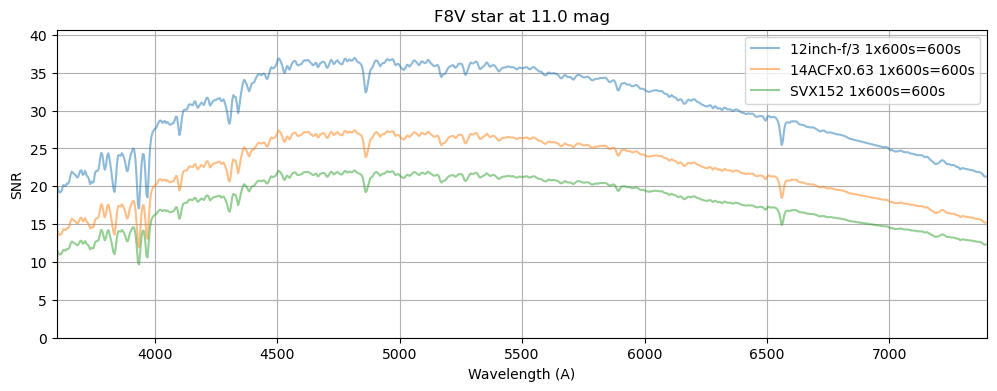

In [15]:
Alpy600.generate_binset(IMX183)
plt.figure(figsize=(12,4))
plt.title(f'{sptype} star at {mag:.1f} mag')
peakSNR = 0
for t,tel in enumerate(telescopes):
    SNR = spectra[tel.name]/variance[tel.name]**0.5
    label = f"{tel.name} {nexp[t]:d}x{exptimes[t]:.0f}s={nexp[t]*exptimes[t]:.0f}s"
    plt.plot(Alpy600.binset, SNR, alpha=0.5, label=label)
    peakSNR = peakSNR if max(SNR) <= peakSNR else max(SNR)
plt.ylabel('SNR')
plt.xlabel('Wavelength (A)')
plt.xlim(min(Alpy600.binset), max(Alpy600.binset))
plt.ylim(0,1.1*peakSNR)
plt.grid()
plt.legend(loc='best')
plt.show()

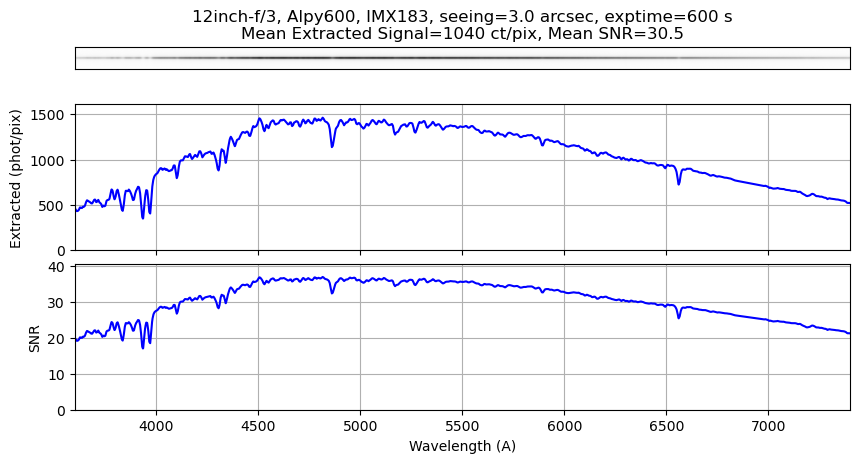

In [16]:
spec, var, im = SpecETC(star, exptime=600*u.second, seeing=3.0*u.arcsec,
                        telescope=Newtonian12, spectrograph=Alpy600, detector=IMX183)

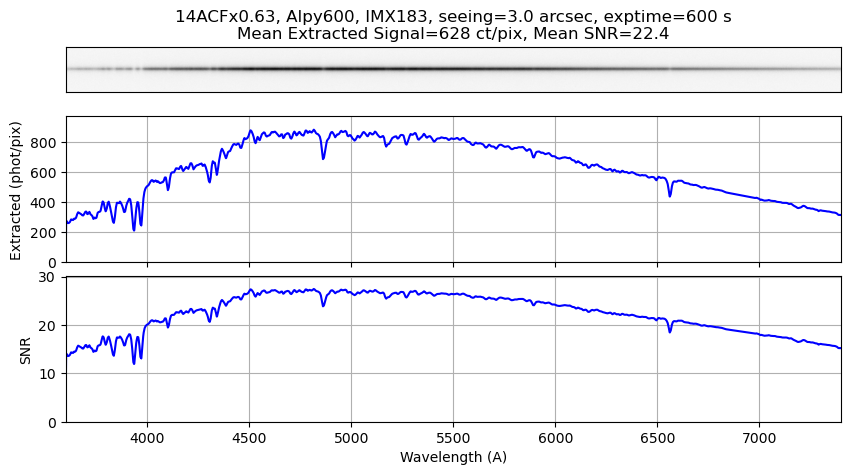

In [17]:
spec, var, im = SpecETC(star, exptime=600*u.second, seeing=3.0*u.arcsec,
                        telescope=ACF14reduced, spectrograph=Alpy600, detector=IMX183)

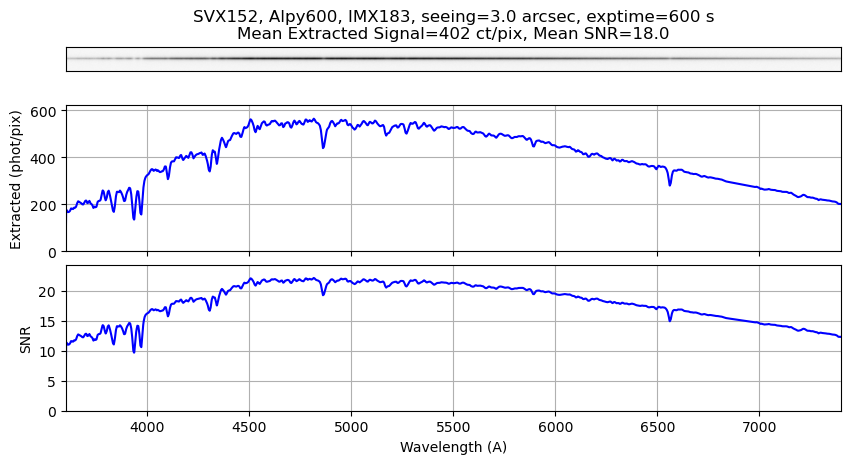

In [18]:
spec, var, im = SpecETC(star, exptime=600*u.second, seeing=3.0*u.arcsec,
                        telescope=SVX152, spectrograph=Alpy600, detector=IMX183)